In [2]:
# Imports
import numpy as np # For storing data and performing computations
SEED = 57131605 # For deterministic testing

In [3]:
# Parse Data
import email
from email import policy
from pathlib import Path

# Parser
def parse_path(path: Path) -> list[str]:
    out = []
    for file in path.glob('*.txt'):
        with open(file=file, mode='r', encoding='latin-1') as f:
            try:
                message = email.message_from_file(f, policy=policy.default)
                subject = message['subject'] or '' # Get subject message (set to an empty string if not provided)
                body = ""
                if message.is_multipart():
                    for part in message.walk():
                        if part.get_content_type() == 'text/plain':
                            body += part.get_content()
                else:
                    body = message.get_content()
                out.append(subject + " " + body)
            except Exception as e:
                print(f'Failed on {file}: {e}')
                return []
    return out

# Parse folders
spam_emails = parse_path(Path('enron1/spam'))
ham_emails = parse_path(Path('enron1/ham'))

In [4]:
# Clean data
import re

# Transform every email string into a list of words
def tokenize(text: str) -> list[str]:
    text = text.lower() # Standard formatting
    text = re.sub(r'\d+', ' ', text) # Remove digits
    text = re.sub(r'\W+', ' ', text) # Remove other erroneous characters
    return text.split()

# Tokenize email strings
spam_tokens = [t for t in map(tokenize, spam_emails)]
ham_tokens = [t for t in map(tokenize, ham_emails)]

In [34]:
# TF-IDF model

# Finding highest frequency counts
word2count = dict()
for lst in spam_tokens + ham_tokens:
    for token in lst:
        if token in word2count:
            word2count[token] += 1
        else:
            word2count[token] = 1

# HYPERPARAMETER: number of words kept -- N_WORDS
N_WORDS = 2000
import heapq
freq_words = set(heapq.nlargest(N_WORDS, word2count, key=word2count.get))

# Truncate Dictionary:
word2count = {w: word2count[w] for w in word2count if w in freq_words}

# Word to Index
WtoI = {w:i for i, w in enumerate(freq_words)}

# Construct word vectors
TF = np.zeros(shape=(5172, 2000), dtype=float)
ys = np.concatenate((np.zeros(shape=(1500,), dtype=int) - 1, np.zeros(shape=(3672,), dtype=int) + 1))

# Construct Bag of Words vectors
for i, tokens in enumerate(spam_tokens + ham_tokens):
    for token in tokens:
        if token in freq_words:
            TF[i, WtoI[token]] += 1 / len(tokens)

IDF = np.log(len(TF) / (np.sum(a=TF, axis=0, keepdims=False) + 1))
xs = TF * IDF

np.random.seed(SEED)
permut = np.random.permutation(len(xs))

xs = xs[permut]
ys = ys[permut]

# Create datasplits
x_train = xs[:4138]
y_train = ys[:4138]
x_test = xs[4138:4655]
y_test = ys[4138:4655]
x_dev = xs[4655:]
y_dev = ys[4655:]

In [35]:
# Soft Margin SVM

# Perform Optimization on Lagrange Multiplier Vector: L
def grad_descent(H, X, Y, C, iters=int(1e3), epsilon=1.0):
    L = np.zeros(shape=(len(X)), dtype=float)
    for _ in range(iters):
        grad = H @ L - 1
        grad = np.clip(grad, -1000, 1000)
        L -= epsilon * grad # Step
        L = np.clip(L, 0, C) # Enforce Non-Negativity
        L = L - Y * (Y @ L) / (Y @ Y + 1e-10) # Project onto Hyperplane to maintain constraint

        if _ % 250 == 0:
            epsilon /= 25
    return L

def train(X, Y, C):
    H = np.outer(Y, Y) * (X @ X.T)
    H /= H.max() # Scale down matrix to control gradient
    H += np.eye(H.shape[0]) * 1e-2 # Reduce eig val spread
    L = grad_descent(H, X, Y, C)

    return L

In [36]:
# Retrieve Weight and bias from Lagrange multiplier vector
def get_param(X, Y, L):
    W = L * Y @ X
    supp_idcs = np.where(L > 0)
    B = np.mean([Y[i] - X[i] @ W for i in supp_idcs])
    return W, B

# Define prediction function
def predict(x, W, B):
    return np.sign(x @ W + B)

def get_accuracy(X, Y, L):
    W, B = get_param(X, Y, L)
    total = 0
    for x, y in zip(X, Y):
        if predict(x, W, B) == y:
            total += 1
    return total / len(X)


In [37]:
# Find best C value
pot_C = np.linspace(0, 10, 100)
acc = np.zeros(len(pot_C))

for i, c in enumerate(pot_C):
    L = train(x_dev, y_dev, c)
    acc[i] = get_accuracy(x_dev, y_dev, L)

pot_C[np.argmax(acc)]

/Users/tudor/CS-Work/ML/P1/SupportVectorMachine/SVM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/tudor/CS-Work/ML/P1/SupportVectorMachine/SVM/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(2.2222222222222223)

In [38]:
# Full Model
C = 2.22 # Best mixing factor based on dev set
L = train(x_test, y_test, C)
W, B = get_param(x_test, y_test, L)

get_accuracy(x_test, y_test, L)

0.9477756286266924

In [39]:
# Make predictions -- For diagnostic tests
y_pred = np.zeros(shape=(517,), dtype=float)
for i, t in enumerate(zip(x_test, y_test)):
    x, y = t
    y_pred[i] = predict(x, W, B)

# Assess Predictions
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Spam", "Ham"]))

              precision    recall  f1-score   support

        Spam       0.90      0.93      0.91       153
         Ham       0.97      0.96      0.96       364

    accuracy                           0.95       517
   macro avg       0.93      0.94      0.94       517
weighted avg       0.95      0.95      0.95       517



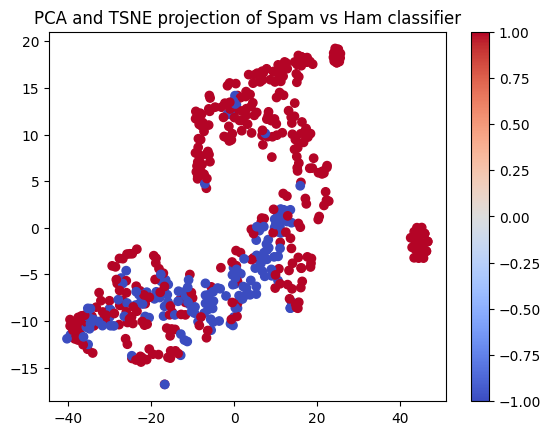

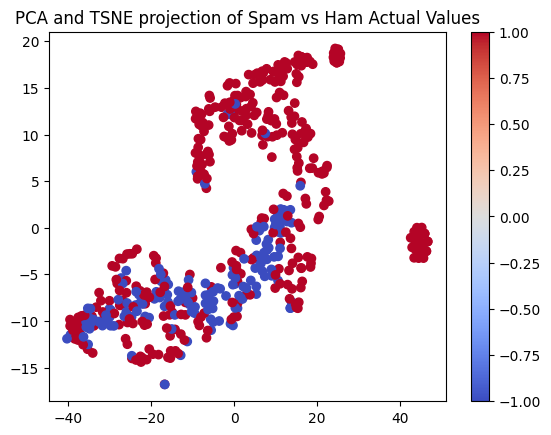

In [40]:
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
x_vis = pca.fit_transform(x_test)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_vis = tsne.fit_transform(x_vis)

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_pred, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham classifier')
plt.show()

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_test, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham Actual Values')
plt.show()